LAB-11:
Segment mall customers by age and spending – discover hidden shopper types


   CustomerID  Gender  Age  Income  SpendingScore
0           1    Male   57      36             53
1           2  Female   35      44             68
2           3  Female   60      55             23
3           4  Female   61      60             54
4           5    Male   59      48             31
(200, 5)
CustomerID        int64
Gender           object
Age               int64
Income            int64
SpendingScore     int64
dtype: object
CustomerID       0
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64
       CustomerID    Age  Income  SpendingScore
count       200.0  200.0   200.0          200.0
mean        100.5   43.3    45.7           48.8
std          57.9   15.5    16.1           19.4
min           1.0   17.0    11.0           -2.0
25%          50.8   28.0    32.8           32.0
50%         100.5   45.0    46.5           50.0
75%         150.2   58.0    58.0           64.0
max         200.0   72.0    87.0           93.0


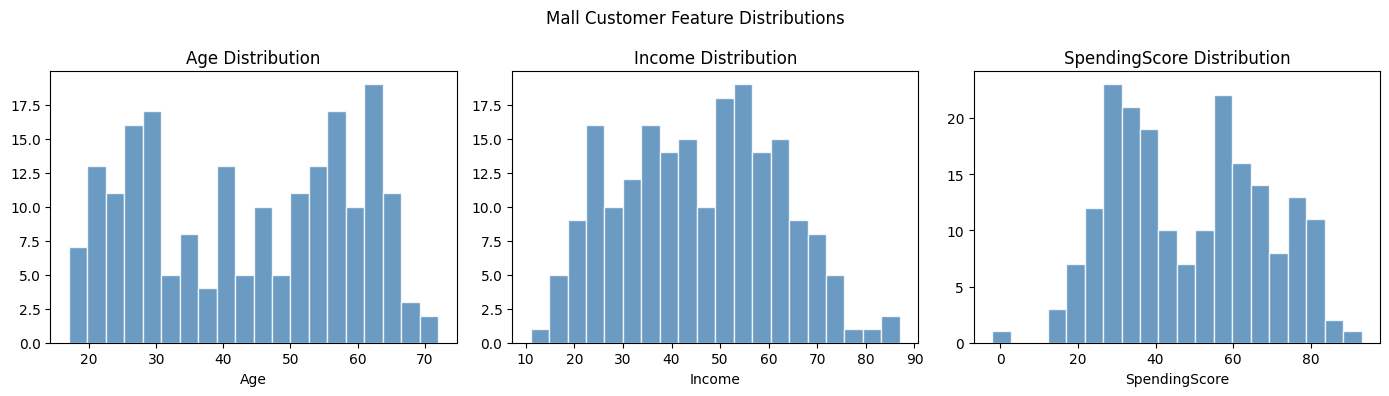

In [3]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# Dataset: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial
# df = pd.read_csv('Mall_Customers.csv') # Original line causing FileNotFoundError

np.random.seed(42)
n_samples = 200

customer_ids = np.arange(1, n_samples + 1)
gender = np.random.choice(['Male', 'Female'], size=n_samples, p=[0.4, 0.6])


age_dist_young = np.random.normal(25, 5, n_samples // 3)
age_dist_mid = np.random.normal(45, 8, n_samples // 3)
age_dist_old = np.random.normal(60, 6, n_samples - 2 * (n_samples // 3))
age = np.concatenate([age_dist_young, age_dist_mid, age_dist_old])
np.random.shuffle(age)
age = age[:n_samples].astype(int)


income_dist_low = np.random.normal(30, 8, n_samples // 3)
income_dist_mid1 = np.random.normal(60, 12, n_samples // 3)
income_dist_mid2 = np.random.normal(50, 10, n_samples - 2 * (n_samples // 3))
income = np.concatenate([income_dist_low, income_dist_mid1, income_dist_mid2])
np.random.shuffle(income)
income = income[:n_samples].astype(int)


spending_dist_high = np.random.normal(70, 10, n_samples // 3)
spending_dist_mid = np.random.normal(50, 15, n_samples // 3)
spending_dist_low = np.random.normal(30, 8, n_samples - 2 * (n_samples // 3))
spending_score = np.concatenate([spending_dist_high, spending_dist_mid, spending_dist_low])
np.random.shuffle(spending_score)
spending_score = spending_score[:n_samples].astype(int)

df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Gender': gender,
    'Age': age,
    'Income': income,
    'SpendingScore': spending_score
})

print(df.head())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe().round(1)) #

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age','Income','SpendingScore']):
  ax.hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
  ax.set_title(f'{col} Distribution'); ax.set_xlabel(col)
plt.suptitle('Mall Customer Feature Distributions'); plt.tight_layout(); plt.show()

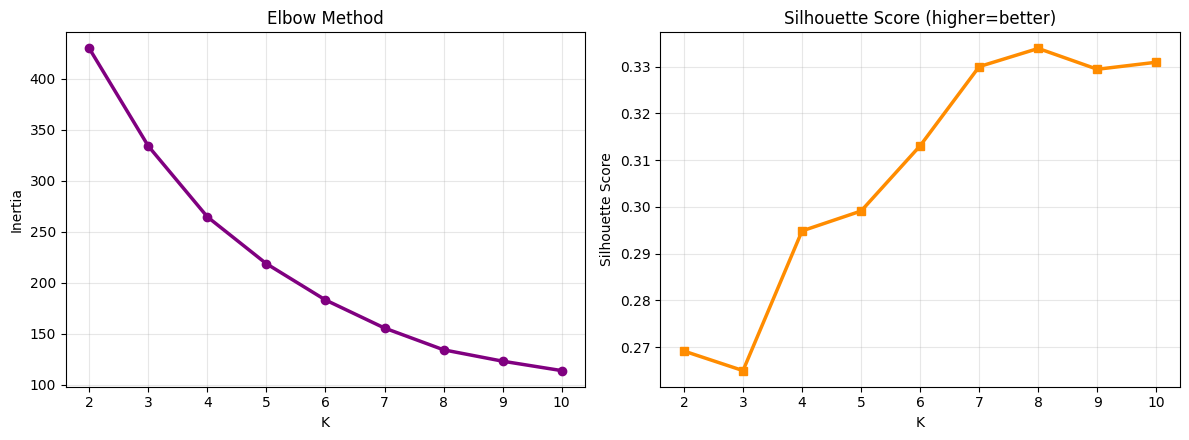

In [4]:

features = ['Age', 'Income', 'SpendingScore']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  km.fit(X_scaled)
  inertias.append(km.inertia_)
  sil_scores.append(silhouette_score(X_scaled, km.labels_))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(K_range, inertias, 'o-', color='purple', lw=2.5)
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method'); ax1.grid(alpha=0.3)
ax2.plot(K_range, sil_scores, 's-', color='darkorange', lw=2.5)
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher=better)'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

          Age             Income             SpendingScore            
         mean   std count   mean   std count          mean   std count
Cluster                                                               
0        56.0   6.6    32   56.8   8.6    32          66.2  10.4    32
1        26.3   5.8    39   51.1  14.2    39          66.7  11.5    39
2        28.9   7.2    44   33.4  11.5    44          38.7  11.4    44
3        53.2  11.3    44   59.8   8.5    44          29.2   9.1    44
4        54.4   8.3    41   29.8   7.2    41          49.9  18.4    41


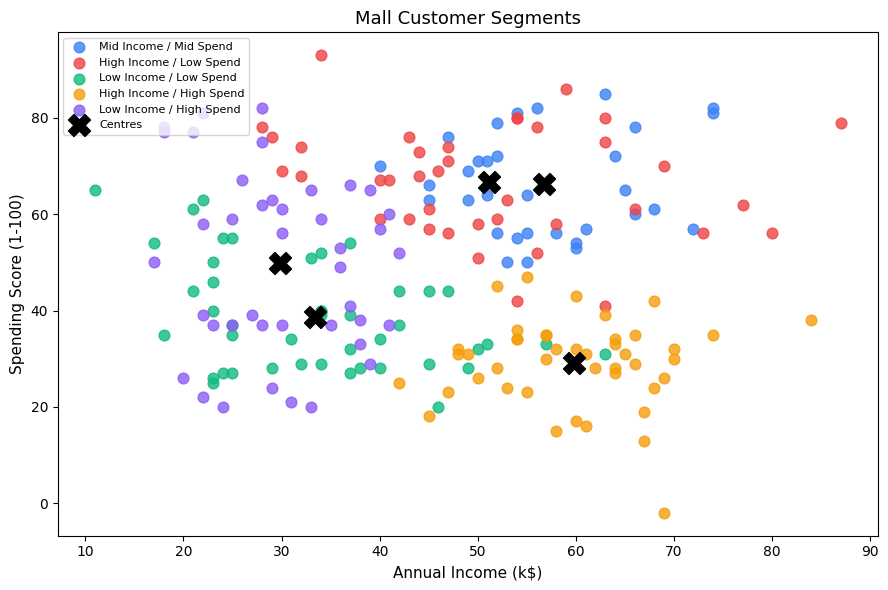

In [6]:
best_k = 5
km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df['Cluster'] = km.fit_predict(X_scaled)
summary = df.groupby('Cluster')[features].agg(['mean','std','count'])
print(summary.round(1))
cluster_labels = {
0: 'Mid Income / Mid Spend',
1: 'High Income / Low Spend',
2: 'Low Income / Low Spend',
3: 'High Income / High Spend',
4: 'Low Income / High Spend',
}
df['Segment'] = df['Cluster'].map(cluster_labels)
palette = ['#3B82F6','#EF4444','#10B981','#F59E0B','#8B5CF6']
plt.figure(figsize=(9, 6))
for c in range(best_k):
  mask = df['Cluster'] == c
  plt.scatter(df[mask]['Income'], df[mask]['SpendingScore'],
    c=palette[c], s=60, alpha=0.8, label=cluster_labels[c])
centres_orig = scaler.inverse_transform(km.cluster_centers_)
plt.scatter(centres_orig[:,1], centres_orig[:,2], c='black',
s=250, marker='X', zorder=5, label='Centres')
plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.title('Mall Customer Segments', fontsize=13)
plt.legend(loc='upper left', fontsize=8); plt.tight_layout(); plt.show()

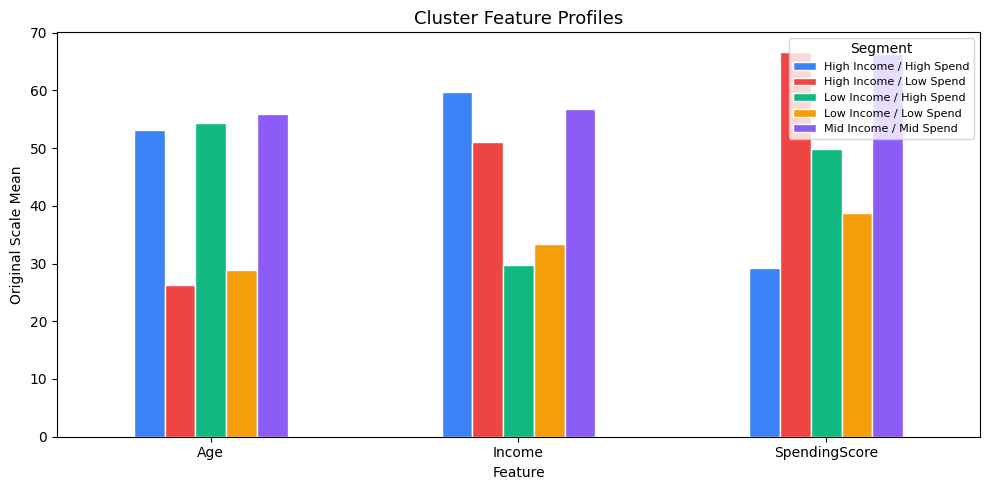


Marketing Strategy Recommendations:
High Income / High Spend: 44 customers
 → Loyalty programmes, premium brands, VIP events

High Income / Low Spend: 39 customers
 → Re-engagement campaigns, personalised offers

Low Income / High Spend: 41 customers
 → Flexible payment, budget promotions, discounts

Low Income / Low Spend: 44 customers
 → Value deals, essentials focus

Mid Income / Mid Spend: 32 customers
 → Broad marketing, seasonal promotions



In [8]:
profile_means = df.groupby('Segment')[features].mean()
profile_means.T.plot(kind='bar', figsize=(10, 5),
color=palette[:best_k], edgecolor='white')
plt.title('Cluster Feature Profiles', fontsize=13)
plt.xlabel('Feature'); plt.ylabel('Original Scale Mean')
plt.legend(title='Segment', fontsize=8, loc='upper right')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
strategies = {
'High Income / High Spend' : '→ Loyalty programmes, premium brands, VIP events',
'High Income / Low Spend' : '→ Re-engagement campaigns, personalised offers',
'Low Income / High Spend' : '→ Flexible payment, budget promotions, discounts',
'Low Income / Low Spend' : '→ Value deals, essentials focus',
'Mid Income / Mid Spend' : '→ Broad marketing, seasonal promotions',
}
print('\nMarketing Strategy Recommendations:')
print('=' * 60)
for seg, strat in strategies.items():
  count = len(df[df['Segment']==seg])
  print(f'{seg}: {count} customers')
  print(f' {strat}\n')